In [11]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("ec2dataset.csv")

In [12]:
print(data.head())

        Name   API Name Instance Memory  \
0   T4G Nano   t4g.nano         0.5 GiB   
1   T3A Nano   t3a.nano         0.5 GiB   
2    T3 Nano    t3.nano         0.5 GiB   
3    T2 Nano    t2.nano         0.5 GiB   
4  T4G Micro  t4g.micro         1.0 GiB   

                                               vCPUs Instance Storage  \
0  2 vCPUs                                       ...         EBS only   
1  2 vCPUs                                       ...         EBS only   
2  2 vCPUs                                       ...         EBS only   
3  1 vCPUs                                       ...         EBS only   
4  2 vCPUs                                       ...         EBS only   

  Network Performance       On Demand Linux Reserved cost  \
0     Up to 5 Gigabit  $0.0042 hourly      $0.0026 hourly   
1     Up to 5 Gigabit  $0.0047 hourly      $0.0029 hourly   
2     Up to 5 Gigabit  $0.0052 hourly      $0.0033 hourly   
3     Low to Moderate  $0.0058 hourly      $0.0036 hourly 

In [13]:
cost_columns = ['On Demand', 'Linux Reserved cost', 'Linux Spot Minimum cost', 'Windows On Demand cost', 'Windows Reserved cost']
for column in cost_columns:
    data[column] = pd.to_numeric(data[column].str.replace('[$, hourly]', '', regex=True), errors='coerce')
print(data[cost_columns].isnull().sum())


On Demand                   20
Linux Reserved cost         24
Linux Spot Minimum cost     39
Windows On Demand cost     263
Windows Reserved cost      266
dtype: int64


In [14]:
cost_summary = data[cost_columns].describe()
print(cost_summary)


        On Demand  Linux Reserved cost  Linux Spot Minimum cost  \
count  841.000000           837.000000               822.000000   
mean     5.188935             3.200449                 0.725993   
std     22.728064            13.904896                 1.775821   
min      0.004200             0.002600                 0.000700   
25%      0.340000             0.215900                 0.103650   
50%      1.563100             0.984800                 0.372600   
75%      4.118000             2.635900                 0.949725   
max    407.680000           251.230800                45.630200   

       Windows On Demand cost  Windows Reserved cost  
count              598.000000             595.000000  
mean                 8.561024               6.297091  
std                 30.135524              20.088637  
min                  0.008100               0.005900  
25%                  0.726900               0.588950  
50%                  3.196000               2.558300  
75%        

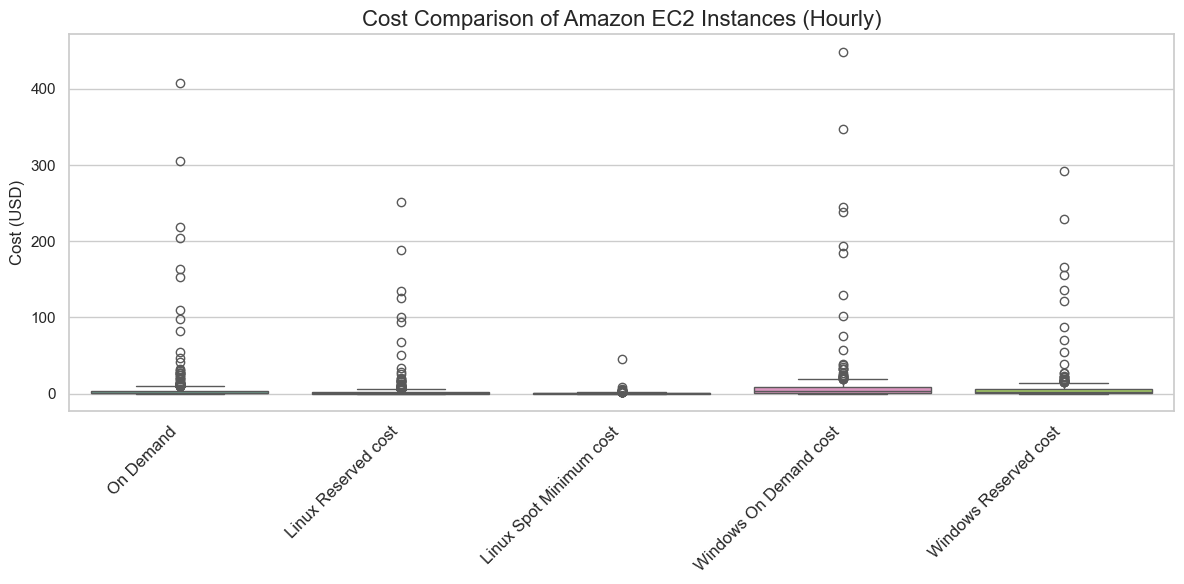

In [15]:
# Set up the plotting style
sns.set_theme(style="whitegrid")
# Create a boxplot to visualize the distribution of costs
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[cost_columns], palette="Set2")

# Set the plot labels and title
plt.title('Cost Comparison of Amazon EC2 Instances (Hourly)', fontsize=16)
plt.ylabel('Cost (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()



In [16]:
# Function to identify outliers using the IQR method
def detect_outliers(column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# Find outliers in the On-Demand cost column
outliers_on_demand = detect_outliers('On Demand')
print(outliers_on_demand)


                    Name             API Name Instance Memory      vCPUs  \
775       C7A Metal-48xl       c7a.metal-48xl       384.0 GiB  192 vCPUs   
776         C7A 48xlarge         c7a.48xlarge       384.0 GiB  192 vCPUs   
777       X2IDN 24xlarge       x2idn.24xlarge      1536.0 GiB   96 vCPUs   
778      X2IEZN 12xlarge      x2iezn.12xlarge      1536.0 GiB   48 vCPUs   
779         X2IEZN Metal         x2iezn.metal      1536.0 GiB   48 vCPUs   
..                   ...                  ...             ...        ...   
836    U-18TB1 112xlarge    u-18tb1.112xlarge     18432.0 GiB  448 vCPUs   
837  U7IN-16TB 224xlarge  u7in-16tb.224xlarge     16384.0 GiB  896 vCPUs   
838    U-24TB1 112xlarge    u-24tb1.112xlarge     24576.0 GiB  448 vCPUs   
839  U7IN-24TB 224xlarge  u7in-24tb.224xlarge     24576.0 GiB  896 vCPUs   
840  U7IN-32TB 224xlarge  u7in-32tb.224xlarge     32768.0 GiB  896 vCPUs   

                                   Instance Storage Network Performance  \
775         

In [17]:
# Compare Reserved and On-Demand costs
cost_comparison = data[['Name', 'On Demand', 'Linux Reserved cost']].dropna().sort_values('On Demand')
print(cost_comparison.head(10))  # Display the top 10 cost-effective instances


        Name  On Demand  Linux Reserved cost
0   T4G Nano     0.0042               0.0026
1   T3A Nano     0.0047               0.0029
2    T3 Nano     0.0052               0.0033
3    T2 Nano     0.0058               0.0036
4  T4G Micro     0.0084               0.0053
5  T3A Micro     0.0094               0.0059
6   T3 Micro     0.0104               0.0065
7   T2 Micro     0.0116               0.0072
8  T4G Small     0.0168               0.0105
9  T3A Small     0.0188               0.0118


#1 It seems that reserved instances specifically the Linux reserved cost, are cheaper then on Demand cost 
#2 It seems the instances that are most cost effective are the T3A small for the most compute for the leaste ammount of money 

In [18]:
# Filter for specific instance families
def filter_instance_family(family):
    return data[data['Name'].str.startswith(family)]
# Example: Filter for T2 and T3 instance families
t2_instances = filter_instance_family('T2')
t3_instances = filter_instance_family('T3')
# Compare summary statistics for T2 and T3 instances
t2_summary = t2_instances[cost_columns].describe()
t3_summary = t3_instances[cost_columns].describe()
print("T2 Instance Costs Summary:\n", t2_summary)
print("\nT3 Instance Costs Summary:\n", t3_summary)


T2 Instance Costs Summary:
        On Demand  Linux Reserved cost  Linux Spot Minimum cost  \
count    7.00000             7.000000                 6.000000   
mean     0.10520             0.065200                 0.026233   
std      0.13306             0.082432                 0.023299   
min      0.00580             0.003600                 0.001900   
25%      0.01730             0.010800                 0.008500   
50%      0.04640             0.028700                 0.019950   
75%      0.13920             0.086250                 0.046700   
max      0.37120             0.230000                 0.055300   

       Windows On Demand cost  Windows Reserved cost  
count                7.000000               7.000000  
mean                 0.128757               0.088786  
std                  0.154409               0.103796  
min                  0.008100               0.005900  
25%                  0.024100               0.017700  
50%                  0.064400               0.0

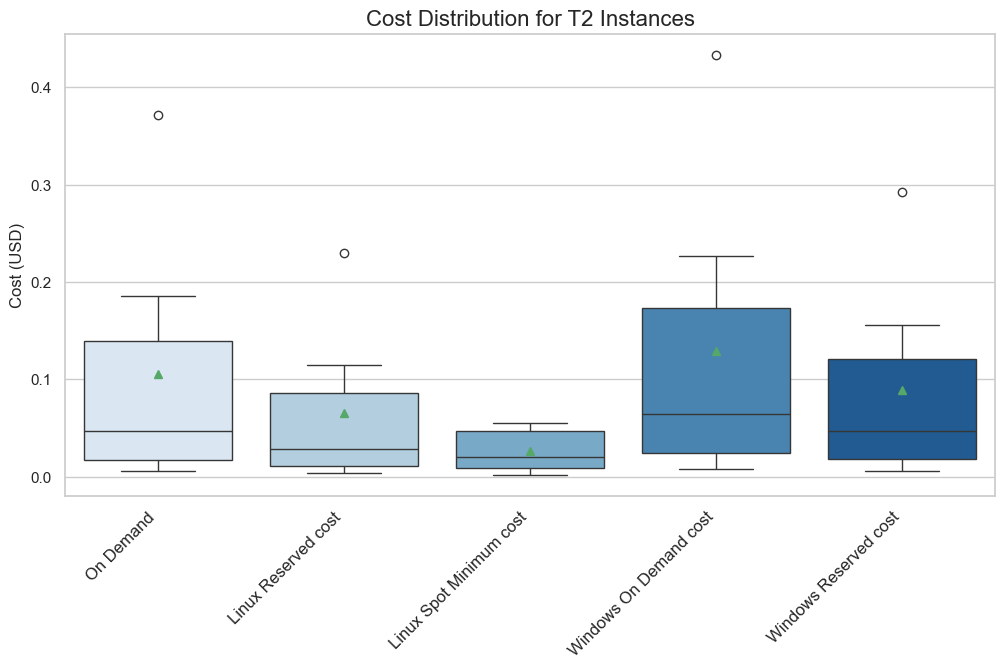

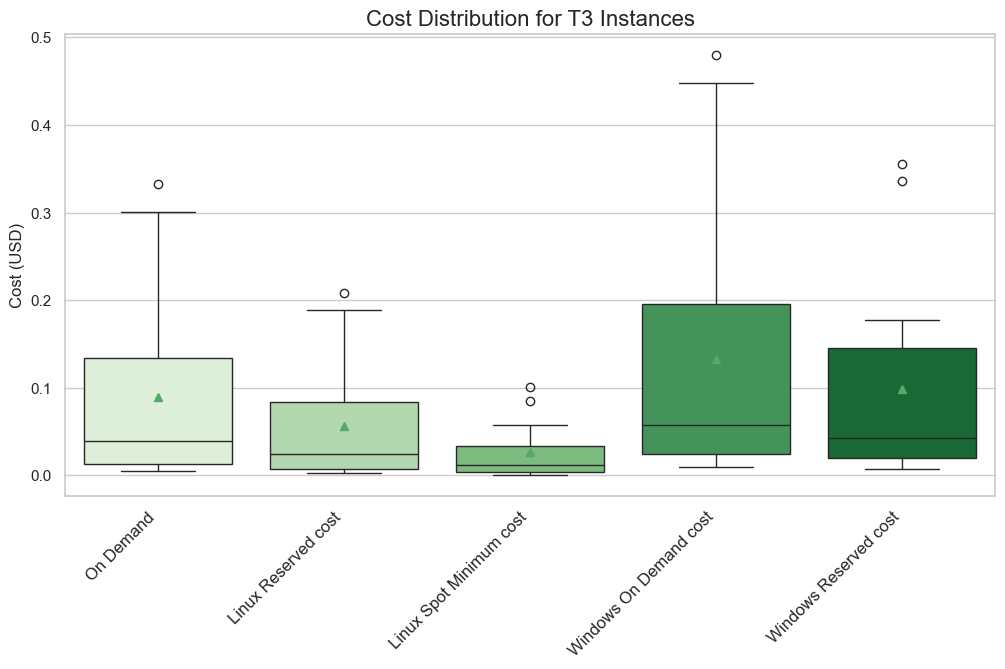

In [19]:
# Visualize cost comparison for T2 and T3 instance families
plt.figure(figsize=(12, 6))
# Add T2 instances
sns.boxplot(data=t2_instances[cost_columns], palette="Blues", showmeans=True)
plt.title('Cost Distribution for T2 Instances', fontsize=16)
plt.ylabel('Cost (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.show()
# Add T3 instances
plt.figure(figsize=(12, 6))
sns.boxplot(data=t3_instances[cost_columns], palette="Greens", showmeans=True)
plt.title('Cost Distribution for T3 Instances', fontsize=16)
plt.ylabel('Cost (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.show()


In [20]:
# Compare On-Demand and Reserved costs for T2 and T3 families
comparison = pd.concat([t2_instances[['Name', 'On Demand', 'Linux Reserved cost']],t3_instances[['Name', 'On Demand', 'Linux Reserved cost']]])
# Sort by On-Demand costs
comparison_sorted = comparison.dropna().sort_values('On Demand')
print(comparison_sorted.head(10))  # Display the 10 lowest-cost instances


          Name  On Demand  Linux Reserved cost
1     T3A Nano     0.0047               0.0029
2      T3 Nano     0.0052               0.0033
3      T2 Nano     0.0058               0.0036
5    T3A Micro     0.0094               0.0059
6     T3 Micro     0.0104               0.0065
7     T2 Micro     0.0116               0.0072
9    T3A Small     0.0188               0.0118
11    T3 Small     0.0208               0.0130
12    T2 Small     0.0230               0.0144
17  T3A Medium     0.0376               0.0236
